<a href="https://colab.research.google.com/github/mudassir7328/Diabetes_Prediction/blob/main/diabetes_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix)

In [3]:
df = pd.read_csv("diabetes.csv")

print("Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())

Shape: (768, 9)

First 5 Rows:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [4]:
print("\nData Info:")
print(df.info())


Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


In [5]:
print("Summary Statistics")
print(df.describe())

Summary Statistics
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232    0.476951  
min      0.00000

In [6]:
print("\nDuplicate Rows:")
print(df.duplicated().sum())


Duplicate Rows:
0


In [7]:
print("\nMissing Values:")
print(df.isnull().sum())



Missing Values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [9]:
# In Diabetes dataset 0 means missing in these columns
zero_columns = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

# Replace 0 with NaN then fill with mean
for col in zero_columns:
    df[col] = df[col].replace(0, np.nan)
    df[col] = df[col].fillna(df[col].mean())

print("\nAfter Fixing Zero/Missing Values:")
print(df.isnull().sum())


After Fixing Zero/Missing Values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


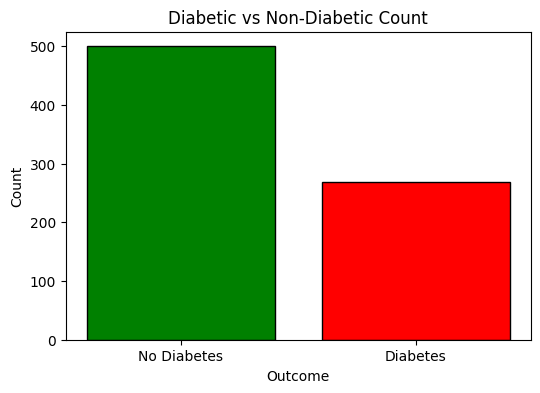


Insight:
The dataset contains more non-diabetic patients than diabetic patients


In [10]:
# GRAPH 1 : Diabetic vs Non-Diabetic Count
plt.figure(figsize=(6, 4))
plt.bar(["No Diabetes", "Diabetes"],
        [sum(df["Outcome"] == 0), sum(df["Outcome"] == 1)],
        color=["green", "red"], edgecolor="black")
plt.title("Diabetic vs Non-Diabetic Count")
plt.xlabel("Outcome")
plt.ylabel("Count")
plt.show()

print("\nInsight:")
print("The dataset contains more non-diabetic patients than diabetic patients")

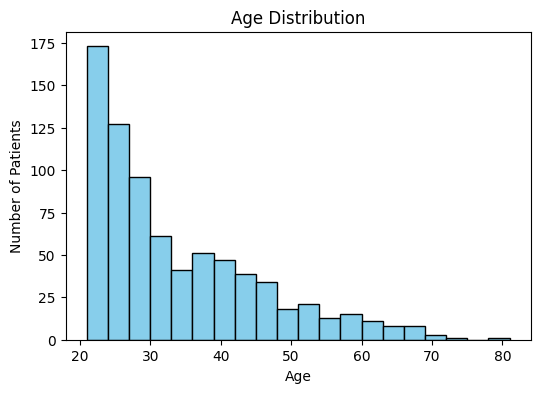


Insight:
Most patients are concentrated in the middle-age group, while relatively fewer patients belong to the younger and older age groups.


In [11]:
# GRAPH 2 : Age Distribution
plt.figure(figsize=(6, 4))
plt.hist(df["Age"], bins=20, color="skyblue", edgecolor="black")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Patients")
plt.show()

print("\nInsight:")
print("Most patients are concentrated in the middle-age group, while relatively fewer patients belong to the younger and older age groups.")


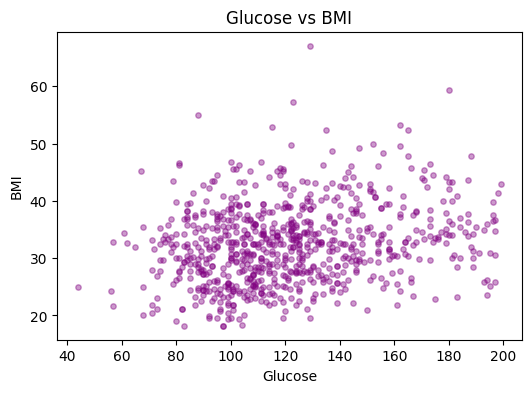


Insight:
Patients with higher glucose levels generally tend to have higher BMI, although the relationship is not perfectly linear.


In [12]:
# GRAPH 3 : Glucose vs BMI
plt.figure(figsize=(6, 4))
plt.scatter(df["Glucose"], df["BMI"], color="purple", alpha=0.4, s=15)
plt.xlabel("Glucose")
plt.ylabel("BMI")
plt.title("Glucose vs BMI")
plt.show()
print("\nInsight:")
print("Patients with higher glucose levels generally tend to have higher BMI, although the relationship is not perfectly linear.")


/tmp/ipykernel_6233/1375060644.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df[col] for col in outlier_cols], labels=outlier_cols)


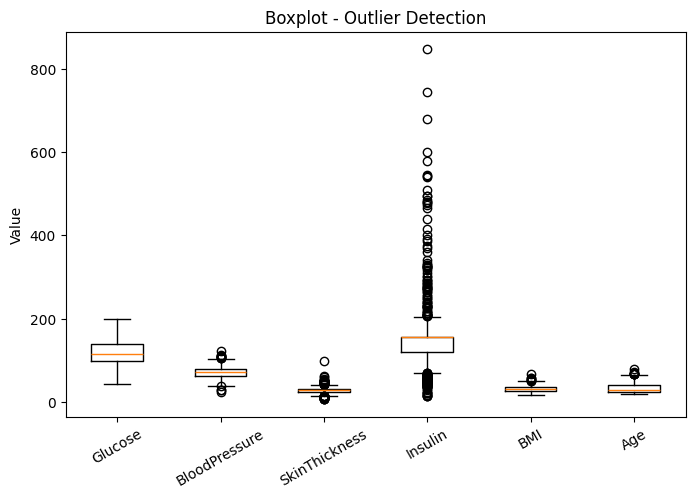

Insight:
  Glucose        : 0 outliers (values outside 39.0 - 201.0)
  BloodPressure  : 14 outliers (values outside 40.0 - 104.0)
  SkinThickness  : 87 outliers (values outside 14.5 - 42.5)
  Insulin        : 164 outliers (values outside 70.4 - 206.6)
  BMI            : 8 outliers (values outside 13.8 - 50.2)
  Age            : 9 outliers (values outside -1.5 - 66.5)


In [13]:
# GRAPH 4 : Boxplot to Detect Outliers
outlier_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI", "Age"]
plt.figure(figsize=(8, 5))
plt.boxplot([df[col] for col in outlier_cols], labels=outlier_cols)
plt.title("Boxplot - Outlier Detection")
plt.ylabel("Value")
plt.xticks(rotation=30)
plt.show()

print("Insight:")
for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outlier_count = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    print(f"  {col:15s}: {outlier_count} outliers (values outside {round(lower,1)} - {round(upper,1)})")


In [14]:
# Remove Outliers using IQR method
print(f"\nShape before removing outliers: {df.shape}")
for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower) & (df[col] <= upper)]

print(f"Shape after removing outliers: {df.shape}")


Shape before removing outliers: (768, 9)
Shape after removing outliers: (490, 9)


In [15]:
X = df.drop(columns=["Outcome"])   # Features
y = df["Outcome"]     # Target (0 = No Diabetes, 1 = Diabetes)

print("\nFeatures (X):")
print(X.columns.tolist())
print("\nTarget (y):", y.name)
print("Target Distribution:")
print(y.value_counts())


Features (X):
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

Target (y): Outcome
Target Distribution:
Outcome
0    310
1    180
Name: count, dtype: int64


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f"\nTraining Size : {X_train.shape}")
print(f"Testing  Size : {X_test.shape}")



Training Size : (392, 8)
Testing  Size : (98, 8)


In [17]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print("\nScaling Done!")


Scaling Done!


In [18]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [19]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

print("\nLogistic Regression Accuracy:", round(accuracy_score(y_test, lr_pred), 3))
print("Random Forest Accuracy:", round(accuracy_score(y_test, y_pred), 3))



Logistic Regression Accuracy: 0.796
Random Forest Accuracy: 0.796


In [20]:
print("\nSample Predictions (first 10):")
print(y_pred[:10])


Sample Predictions (first 10):
[1 0 0 1 0 0 0 0 0 0]


In [21]:
comparison = pd.DataFrame({
    "Actual"    : y_test.iloc[:10].values,
    "Predicted" : np.round(y_pred[:10], 2),
    "Result"    : ["Correct" if a == p else "Wrong"
                   for a, p in zip(y_test.iloc[:10], y_pred[:10])]
})

print("\nActual vs Predicted (first 10 rows):")
print(comparison.to_string(index=False))


Actual vs Predicted (first 10 rows):
 Actual  Predicted  Result
      1          1 Correct
      0          0 Correct
      0          0 Correct
      0          1   Wrong
      1          0   Wrong
      0          0 Correct
      1          0   Wrong
      0          0 Correct
      1          0   Wrong
      0          0 Correct


In [22]:
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("----------MODEL PERFORMANCE STATS----------")
print(f"  Accuracy  : {round(accuracy  * 100,2)}%")
print(f"  Precision : {round(precision * 100,2)}%")
print(f"  Recall    : {round(recall * 100, 2)}%")
print(f"  F1-Score  : {round(f1 * 100, 2)}%")

----------MODEL PERFORMANCE STATS----------
  Accuracy  : 79.59%
  Precision : 80.0%
  Recall    : 57.14%
  F1-Score  : 66.67%


In [23]:
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)
print(f"\n  True  Negative  (Correctly predicted No Diabetes) : {cm[0][0]}")
print(f"  False Positive  (Wrongly predicted Diabetes)       : {cm[0][1]}")
print(f"  False Negative  (Wrongly predicted No Diabetes)    : {cm[1][0]}")
print(f"  True  Positive  (Correctly predicted Diabetes)     : {cm[1][1]}")


Confusion Matrix:
[[58  5]
 [15 20]]

  True  Negative  (Correctly predicted No Diabetes) : 58
  False Positive  (Wrongly predicted Diabetes)       : 5
  False Negative  (Wrongly predicted No Diabetes)    : 15
  True  Positive  (Correctly predicted Diabetes)     : 20


In [24]:
print("\n------- Predict New Patient -------")

try:
    pregnancies = float(input("Enter Pregnancies            : "))
    glucose = float(input("Enter Glucose                : "))
    bp = float(input("Enter Blood Pressure         : "))
    skin = float(input("Enter Skin Thickness         : "))
    insulin = float(input("Enter Insulin                : "))
    bmi = float(input("Enter BMI                    : "))
    dpf = float(input("Enter Diabetes Pedigree Func : "))
    age = float(input("Enter Age                    : "))

    user_input_df = pd.DataFrame([{
        "Pregnancies": pregnancies,
        "Glucose": glucose,
        "BloodPressure": bp,
        "SkinThickness": skin,
        "Insulin": insulin,
        "BMI": bmi,
        "DiabetesPedigreeFunction": dpf,
        "Age": age
    }])

    user_input_scaled = scaler.transform(user_input_df)

    prediction = model.predict(user_input_scaled)[0]


    result = "Diabetic" if prediction == 1 else "Not Diabetic"
    print(f"Prediction : {result}")


except Exception as e:
    print("An error occurred:", e)


------- Predict New Patient -------
Enter Pregnancies            : 6 
Enter Glucose                : 148
Enter Blood Pressure         : 72              
Enter Skin Thickness         : 35        
Enter Insulin                : 0 
Enter BMI                    : 33.6
Enter Diabetes Pedigree Func : 0.627
Enter Age                    : 50
Prediction : Diabetic
